In [1]:
# initialize Otter
import otter
grader = otter.Notebook("hw3-task2.ipynb")

# Homework 3 - Task 2: Tree-Based Methods
## Predicting Water Potability Using Decision Trees and Random Forests

---


### Dataset

Access to safe drinking water is a fundamental public health concern. This dataset contains physicochemical measurements for 3,276 water samples, each labeled as potable or non-potable.

| Feature | Description |
|---|---|
| `ph` | pH value of water (0–14 scale) |
| `Hardness` | Capacity to precipitate soap (mg/L) |
| `Solids` | Total dissolved solids (ppm) |
| `Chloramines` | Amount of chloramines (ppm) |
| `Sulfate` | Amount of sulfates dissolved (mg/L) |
| `Conductivity` | Electrical conductivity (μS/cm) |
| `Organic_carbon` | Amount of organic carbon (ppm) |
| `Trihalomethanes` | Amount of trihalomethanes (μg/L) |
| `Turbidity` | Measure of light-emitting property (NTU) |

#### Response Variable

| Column | Description |
|---|---|
| `Potability` | Binary flag — `1` if water is safe to drink, `0` otherwise |


 **Note:** Several features contain missing values (`ph`, `Sulfate`, `Trihalomethanes`). You will handle these in the preprocessing step.

 This dataset comes from Kaggle and can be found [here](https://www.kaggle.com/datasets/uom190346a/water-quality-and-potability).

### Setup: Load Libraries

Run the cell below to import all required packages.

In [2]:
# load necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


### Step 1: Load the Data

Read `water_potability.csv` into a DataFrame. Preview the first few rows and confirm its shape.

In [3]:
# read in potable water data
df = pd.read_csv('water_potability.csv')

# view data dimensions
print(f'Shape: {df.shape}')

# view data 
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Step 2: Explore the Data

Before modeling, examine the distribution of your response variable and the number of NAs. Understanding both will guide preprocessing decisions.

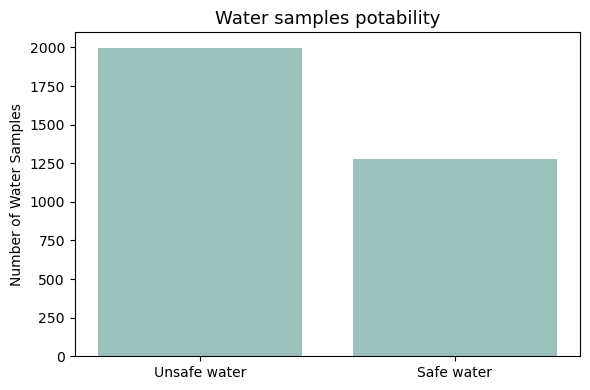

In [4]:
# count water samples with unsafe and safe drinking water
counts = df['Potability'].value_counts().sort_index()

labels = ['Unsafe water', 'Safe water']

# visualize water sample potability
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, counts.values, color = '#9BC1BC')
ax.set_title('Water samples potability', fontsize=13)
ax.set_ylabel('Number of Water Samples')
plt.tight_layout()
plt.show()

In [5]:
# view which columns in the dataframe have NA values
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

### Step 3: Preprocess the Data

Three features have missing values. A simple approach for tree-based methods is to **impute with the column median**. Impute the missing values using `df.fillna()`.Store your cleaned dataframe in a variable called `df_clean`. 

After imputation, split the data 70/30 into training and test sets, stratifying on `Potability` to preserve the class ratio in both splits.Store your results in `X_train`, `X_test`, `y_train`, and `y_test`.

In [6]:
# fill the NAs with the median of each column
df_clean = df.fillna(df.median())

# select everything but heating load
features = [c for c in df_clean.columns if c != 'Potability']

# define the reponse and predictor variables
X = df_clean[features]
y = df_clean['Potability']

# create test and training sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state= 42, stratify= y)

In [7]:
# ensure the fill na worked
df_clean.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [8]:
grader.check("q1")

q1 results: All test cases passed!

### Step 4: Fit a Single Classification Tree

Start with an **unpruned** classification tree (no constraints on depth or leaf size). This gives a baseline and illustrates the overfitting problem that ensemble methods address.

Fit `DecisionTreeClassifier` with only `random_state=42` set (all other parameters at defaults). Report the tree depth in a variable named `tree_depth`. Calculate both the train accuracy and the test accuracy, storing the train accuracy in a variable called`dt_unpruned_acc_train` and the test accuracy in a variable called `dt_unpruned_acc_test`. 

In [9]:
# fit a decision tree without specifying a depth
dt_unpruned = DecisionTreeClassifier(random_state = 42)
dt_unpruned.fit(X_train, y_train)

# view the decision tree depth
tree_depth = dt_unpruned.get_depth()

# assess the accuracy of the decision tree
dt_unpruned_acc_train = accuracy_score(y_train, dt_unpruned.predict(X_train))
dt_unpruned_acc_test  = accuracy_score(y_test, dt_unpruned.predict(X_test))

print(f"The training accuracy is", dt_unpruned_acc_train)
print(f"The test accuracy is", dt_unpruned_acc_test)

The training accuracy is 1.0
The test accuracy is 0.5808748728382502


In [10]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: How does the training accuracy and test accuracy differ? What does this mean about your model?**

The training accuracy is 1 and the test accuracy is approximately 0.58. This means that the decision tree fits the training data perfectly and is over fitting this data. The variance of the decision tree model without any depth set is extremely high.

<!-- END QUESTION -->

### Step 5: Tune Tree Depth with Cross-Validation

A fully grown tree memorizes the training data (better training accuracy, poor test accuracy). We need to find the right **depth** to prevent this. 

Using 5-fold cross-validation on the training set, compute mean CV accuracy for `max_depth` from 1 to 20. Identify the optimal depth using `np.argmax`, storing it in a variable called `optimal_depth`. Plot the CV Accuracy against the 20 different depths, adding a vertical line at the optimal depth. 

In [11]:
# set the depths to iterate through
depths = range(1, 21)

# create an empty list to store the accuracy means per depth
cv_means = []

# iterate through the decision tree to assess what depth is best
for depth in depths:
    dt = DecisionTreeClassifier(max_depth = depth, random_state = 42)
    scores = cross_val_score(dt, X_train, y_train, cv = 5, scoring = 'accuracy')
    cv_means.append(scores.mean())

# set the mean to an array
cv_means = np.array(cv_means)

# find the optimal depth for the decision tree
optimal_depth   = list(depths)[np.argmax(cv_means)]

print(f"Best max_depth (5-fold CV): {optimal_depth}  (CV accuracy: {cv_means.max():.3f})")

Best max_depth (5-fold CV): 7  (CV accuracy: 0.639)


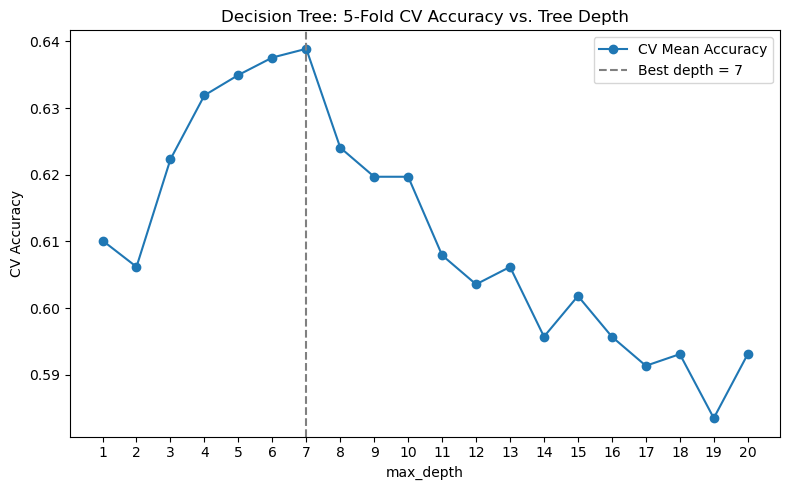

In [12]:
# visualize the tree depth and the mean accuracy 
plt.figure(figsize = (8, 5))
plt.plot(list(depths), cv_means, label='CV Mean Accuracy', marker='o')
plt.axvline(optimal_depth, color='gray', linestyle='--', label=f'Best depth = {optimal_depth}')
plt.xlabel('max_depth')
plt.ylabel('CV Accuracy')
plt.xticks(list(depths))
plt.title('Decision Tree: 5-Fold CV Accuracy vs. Tree Depth')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2: What did cross fold validation find the optimal depth to be? Explain what these means in plain language.**

The optimal depth is 5 according to the cross fold validation. The tree is divided 5 times to create classifications that encapsulate the true groupings based on the predictors.

<!-- END QUESTION -->

### Step 6: Fit the Tuned Decision Tree

Refit the decision tree using `optimal_depth` and evaluate on the held-out test set. Store the test accuracy in a variable called `acc_dt`. 

In [14]:
# fit a decision tree with the optimal depth
dt_opt = DecisionTreeClassifier(random_state = 42, max_depth = optimal_depth)
dt_opt.fit(X_train, y_train)

# save the accuracy score of the decision tree with the optimal depth
acc_dt    = accuracy_score(y_test, dt_opt.predict(X_test))

print(f"The test accuracy when using the optimal depth is", acc_dt)
print(f"The test accuracy when no depth was set is", dt_unpruned_acc_test)

The test accuracy when using the optimal depth is 0.6459816887080366
The test accuracy when no depth was set is 0.5808748728382502


In [15]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q3: Did the accuracy on your tuned decision tree imrpove compared to your untuned tree? If so, why do you think it improved?**

The test accuracy when using the optimal depth in a decision tree is approximately 0.65 while the test accuracy when no depth was set is 0.58. This is a drastic improvement in the test accuracy from the untuned tree to the optimal depth decision tree. This improvement is because the model is no longer overfitting. The untuned tree was categorizing the observations down to each observation being in its own leaf. The model with the optimal depth is more generalizable and doesn't have as high of variance. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 7: Visualize the Decision Tree

Plot the tuned tree using `plot_tree`. Save the tree as an image to evaluate the results and answer **Q5**. 

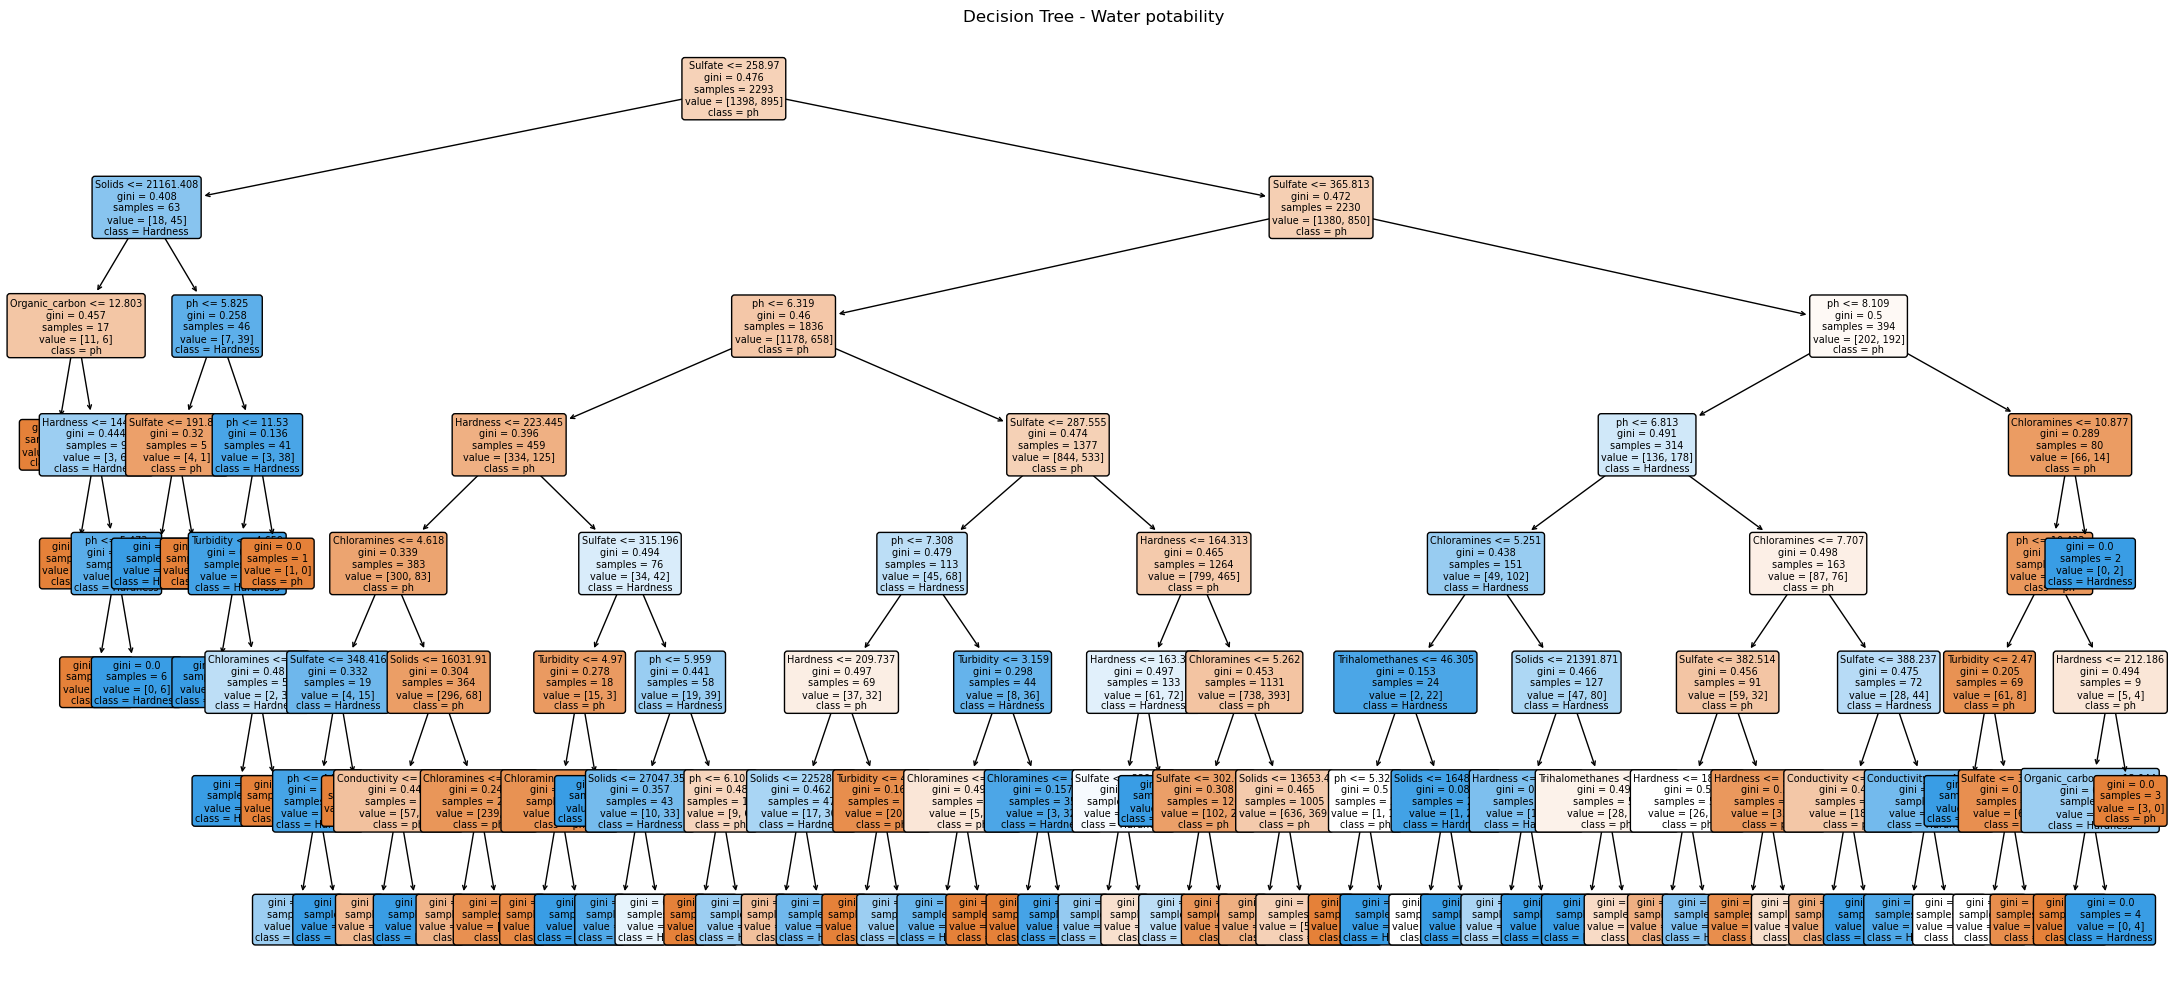

In [16]:
# visualize the decision tree
plt.figure(figsize=(22,10))
class_names = features
plot_tree(dt_opt, 
          feature_names=features, 
          class_names=class_names, 
          filled = True, 
          rounded = True, 
          fontsize = 7)
plt.title('Decision Tree - Water potability')
plt.tight_layout()
plt.show()

> **Q4: Examine the root node and first two levels of the tree. Which feature is used for the root split, and what threshold does it use? What does this tell you about that feature's relationship with potability? What is the Gini impurity at the root, and how does it change after the first split?**

Sulfate is the feature at the root split. The threshold is less than 258.97 or greater than or equal to 258.97. Sulfate is the variable that most defines whether a water test response will be potable or unpotable. The gini impurity goes down as we move down the tree. The closer the gini impurity value gets to zero the more pure the classification group is. The bottom right corner has a gini impurity value of zero meaning that the classification group is entirely made up of one class. 

<!-- END QUESTION -->

### Step 8: Random Forest

**Random forests** address the high variance of a single tree by fitting many trees on bootstrap samples of the training data and averaging their predictions. To further reduce correlation among the trees, at each split only a random subset of $m$ features is considered (by default sklearn uses $m = \lfloor\sqrt{p}\rfloor$ for classification).

Fit a `RandomForestClassifier`, called `rf` with `n_estimators=200`. Report the accuracy and store it in `acc_rf`. 

In [17]:
# fit a random forest classifier
rf = RandomForestClassifier(n_estimators = 200, random_state = 42)
rf.fit(X_train, y_train)

# save the random forest accuracy
acc_rf    = accuracy_score(y_test, rf.predict(X_test))

# view the random forest accuracy
acc_rf

0.6642929806714141

In [18]:
grader.check("q5")

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError

In [19]:
print(f"The test accuracy is ", acc_dt, " for the decision tree model")
print(f"The test accuracy is ", acc_rf, "for the random forest model")

The test accuracy is  0.6459816887080366  for the decision tree model
The test accuracy is  0.6642929806714141 for the random forest model


<!-- BEGIN QUESTION -->

>**Q5: Compare the test results of Decision Tree and Random Forest? Which performed beter? Why do you think this is?**

The random forest test accuracy is higher than the test accuracy for the decision tree. The decision tree test accuracy is approximately 0.645 while the random forest test accuracy is approximately 0.664. The random forest accuracy performed better. The random forest classifier reduces correlation of the trees by only using a random subset of variables at each split. This reduces the variance for the model and makes it more generalizable. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 9: Feature Importances

Both decision trees and random forests assign an **importance score** to each feature based on the total reduction in impurity (Gini) it produces across all splits. Random forest importances are averaged over all trees in the ensemble, making them more stable than a single tree's importances.

Create a bar plot showing the feature importances from the tuned decision tree and the random forest side by side. You can access the feature importants from the model wtih `model.feature_importances_`.

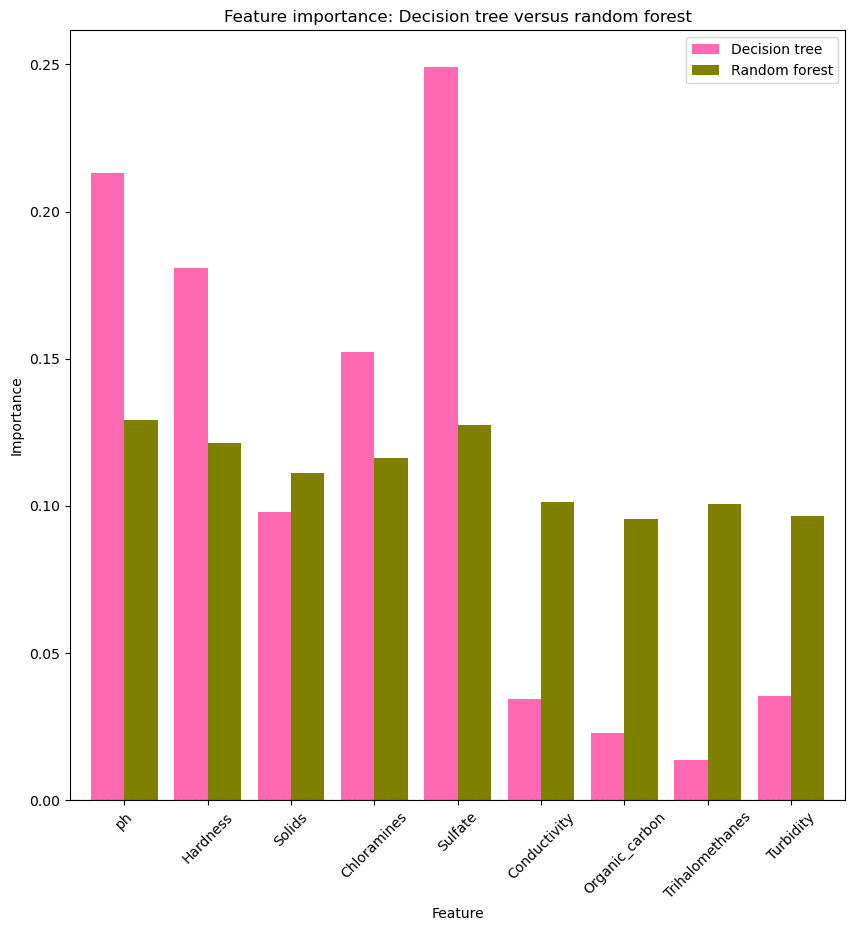

In [20]:
# create a dataframe for feature importance 
feature_imp = pd.DataFrame({'Feature' : features,
              'Decision tree' : dt_opt.feature_importances_,
              'Random forest' : rf.feature_importances_})


# visualize feature importance differences between the decision tree and random forest
fig, ax = plt.subplots(figsize=(10, 10))
ax = ax

ax = feature_imp.plot(x = 'Feature', 
                        y = ['Decision tree', 'Random forest'],
                        color = ['hotpink', 'olive'], 
                        kind = 'bar', 
                        width=0.8,
                        ax = ax)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticklabels(feature_imp['Feature'], rotation=45)

plt.title('Feature importance: Decision tree versus random forest')
    
plt.ylabel('Importance')
plt.show()

> **Q6: Do the decision tree and random forest agree on which features are most important? If they differ, why might a single tree's importances be less reliable than the random forest's? Which feature appears most important for predicting potability, and does that make physical sense?**

The decision tree and random forest do not agree on which features are most important. The random forest finds all of the features important while the decision tree only finds a few of the features to be important. These differ because the random forest takes an average of all of the bootstrap samples decision trees of the training data. A single tree is less reliable because it has high variance meaning it can vary greatly based on the training data.

<!-- END QUESTION -->

### Step 10: Confusion Matrix

Create a confusion matrix for the random forest model using `ConfusionMatrixDisplay`. Label your response variable as `Not Potable`/ `Potable` in the confusion matrix (instead of `0`/`1`).

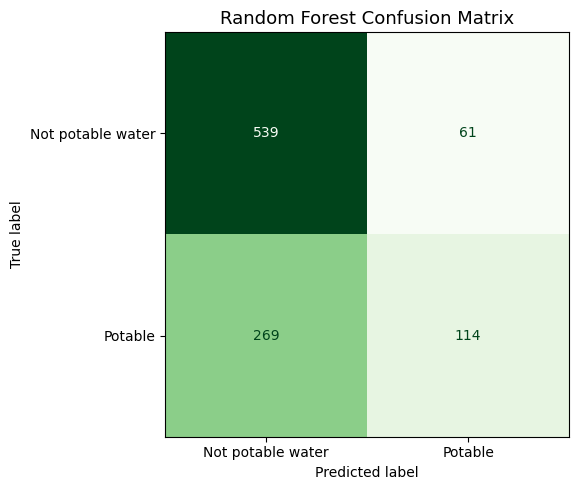

In [21]:
# create a confustion matrix from the random forest model 
cm = confusion_matrix(y_test, rf.predict(X_test))

# display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix = cm,
                              display_labels = ["Not potable water", "Potable"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax = ax, colorbar = False, cmap = 'Greens')
ax.set_ylim(len(["Potable", "Not potable water"]) - 0.5, -0.5)
ax.set_title('Random Forest Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()


<!-- BEGIN QUESTION -->

> **Q7:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

False Positives: 61
True Positives: 114
False Negatives: 269
True Negatives: 539

There are 61 instances when the true water testing result is not potable water but the predicted water testing result is potable water. 
There are 114 instances when the true water testing result is potable water and the predicted water testing result is accurately defined as potable water.
There are 269 instances when the true water testing result is potable water and the predicted water testing result is inaccurately presicted as not potable water.
There are 539 instances when the true water testing result is not potable water and the predicted water testing is accurately defined as not potable water.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 11: Model Comparison

Create a table or bar chart comparing test accuracy across all three models.

In [22]:
# create a table to visualize the test accuracy across the three models
test_accuracy = pd.DataFrame({'Model' : ['Decision Tree (depth undefined)', 'Decision Tree (optimal depth)', 'Random forest'],
                              'Test accuracy' : [dt_unpruned_acc_test, acc_dt, acc_rf]})

# view the test accuracy table
test_accuracy


,Model,Test accuracy
0,Decision Tree (depth undefined),0.580875
1,Decision Tree (optimal depth),0.645982
2,Random forest,0.664293


> **Q8:** Which model achieved the highest test accuracy? Comparing the unpruned and tuned decision tree, how much did pruning improve accuracy? What does this tell you about overfitting in the unpruned tree?


The random forest model achieved the highest test accuracy with a test accuracy of approximately 0.66. Addittionally, modelling the decision tree with the optimal depth as opposed to a decision tree with no pre-defined depth improved test accuracy significantly. The test accuracy improved from approximately 0.581 with the untuned tree to approximately 0.646 using the optimal depth decision tree. The unpruned tree overfits significantly. The decision tree with no defined depth is categorized until each point has its own classification. The decision tree run on the optimal depth prevents this overfitting issue. 

---

Run the cell below to receive credit for autograded questions. 

In [23]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError